In [3]:
import pandas as pd
import numpy as np
import scipy
import statsmodels as sm
import matplotlib.pyplot as plt
import seaborn as sns
import plotly 
import streamlit

In [4]:
df = pd.read_csv("medical_insurance.csv")

## EDA

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229
2771,54,male,31.600,0,no,southwest,9850.43200


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1435)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [11]:
df.reset_index(drop=True)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830
1333,18,female,31.920,0,no,northeast,2205.98080
1334,18,female,36.850,0,no,southeast,1629.83350
1335,21,female,25.800,0,no,southwest,2007.94500


In [12]:
num_cols = ['age', 'bmi', 'children', 'charges']
desc = pd.DataFrame({
    'mean': df[num_cols].mean(), 'median': df[num_cols].median(),
    'std': df[num_cols].std(), 'IQR': df[num_cols].quantile(.75) - df[num_cols].quantile(.25),
    'skew': df[num_cols].skew(), 'kurtosis': df[num_cols].kurt()
}).round(3)

In [13]:
desc

,mean,median,std,IQR,skew,kurtosis
age,39.222,39.000,14.044,24.000,0.055,-1.244
bmi,30.663,30.400,6.100,8.410,0.284,-0.053
children,1.096,1.000,1.206,2.000,0.937,0.201
charges,13279.121,9386.161,12110.360,11911.373,1.515,1.604


The mean and median are nearly the same for the features but the charges differ a lot showing sensitivityof mean to larger values. The childeren attribute is moderately right-skewed (0.937). Most people have 0 or 1 children, with the frequency dropping off sharply for higher numbers.

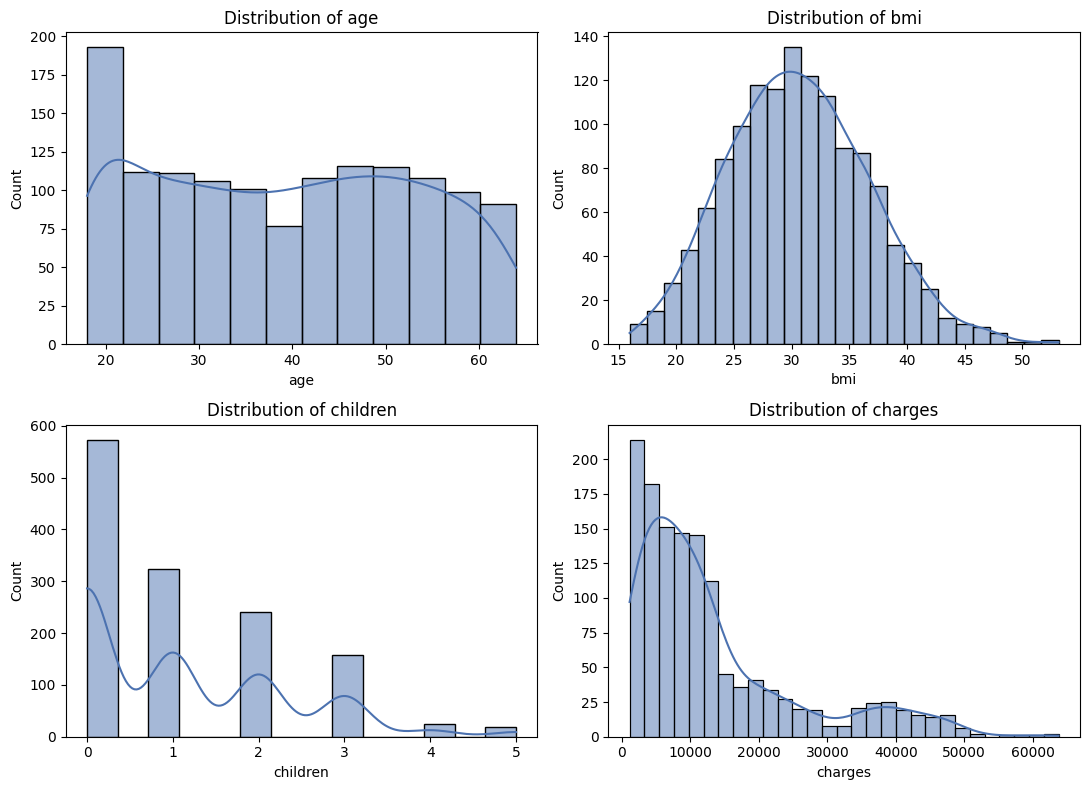

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

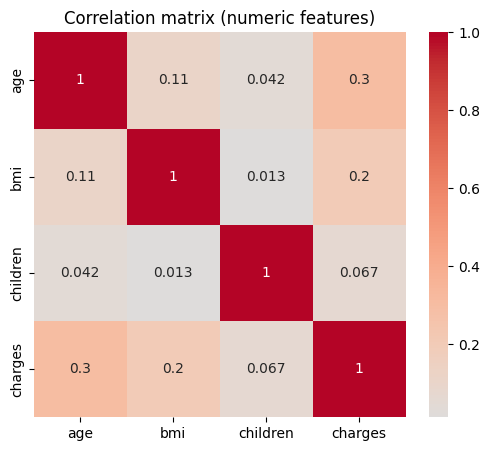

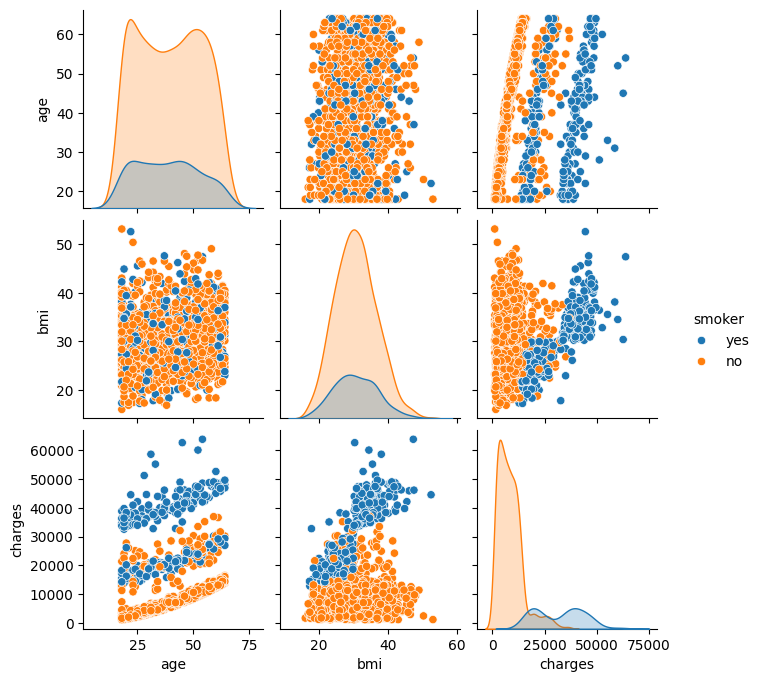

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (numeric features)")
plt.show()

sns.pairplot(df, vars=['age', 'bmi', 'charges'], hue='smoker', diag_kind='kde', height=2.3)
plt.show()

For non-smokers, a higher BMI has almost no visible impact on medical charges (the orange dots remain flat and clustered near the bottom). However, for smokers, there is a massive, sudden spike in charges once their BMI crosses approximately the 30 mark, demonstrating a severe compounding health risk effect.

In age vs bmi, The plot is a scattered, uniform cloud of points, confirming there is no meaningful correlation between a person's age and their BMI in this data

## Hypothesis Test 1: Smokers vs. Non-Smokers on `charges`

We're comparing a continuous variable (`charges`) between two independent groups (`smoker` = yes/no).

- **H0:** No difference in mean/distribution of charges between smokers and non-smokers.
- **H1:** There is a significant difference.

1. **Shapiro-Wilk** on each group checks normality (H0 of Shapiro = "data is normal"; a small p-value means we *reject* normality).
2. **Levene's test** checks equal variance across the two groups.

Only if both hold do we run a **Welch/Student's t-test**; otherwise we fall back to the **Mann-Whitney U test**, a non-parametric test that compares distributions/ranks instead of means and makes no normality assumption.

In [16]:
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [17]:
smokers = df.loc[df.smoker == 'yes', 'charges']
nonsmokers = df.loc[df.smoker == 'no', 'charges']

# Shapiro-Wilk normality check (sampled to 500 per group — Shapiro is unreliable/overly powered on very large n)
sw_smoke = stats.shapiro(smokers.sample(min(500, len(smokers)), random_state=1))
sw_non = stats.shapiro(nonsmokers.sample(min(500, len(nonsmokers)), random_state=1))
print("Shapiro-Wilk (smokers):     stat=%.4f, p=%.3e" % sw_smoke)
print("Shapiro-Wilk (non-smokers): stat=%.4f, p=%.3e" % sw_non)

# Levene's test for equal variance
lev = stats.levene(smokers, nonsmokers)
print("\nLevene's test: stat=%.4f, p=%.3e" % lev)

Shapiro-Wilk (smokers):     stat=0.9396, p=3.625e-09
Shapiro-Wilk (non-smokers): stat=0.8715, p=6.856e-20

Levene's test: stat=332.4714, p=1.670e-66


Both Shapiro-Wilk p-values are far below 0.05 → we reject normality for *both* groups. Levene's p-value is also far below 0.05 → variances are unequal too. Both t-test assumptions fail, so per the assignment's decision rule we use the **Mann-Whitney U test** instead of a t-test.

In [18]:
u_stat, p_val = stats.mannwhitneyu(smokers, nonsmokers, alternative='two-sided')
print("Mann-Whitney U statistic:", u_stat)
print("p-value: %.3e" % p_val)

print("\nMedian charges — smokers: %.2f | non-smokers: %.2f" % (smokers.median(), nonsmokers.median()))

alpha = 0.05
conclusion = "Reject H0" if p_val < alpha else "Fail to Reject H0"
print(f"\nAt alpha = {alpha}: {conclusion} — smokers and non-smokers have significantly different charge distributions.")

Mann-Whitney U statistic: 283859.0
p-value: 5.747e-130

Median charges — smokers: 34456.35 | non-smokers: 7345.73

At alpha = 0.05: Reject H0 — smokers and non-smokers have significantly different charge distributions.


**Conclusion:** p ≈ 5.7e-130, far below α = 0.05 → **Reject H0**. Smokers' median charge (≈ 34,456) is roughly 4.7× non-smokers' median (≈ 7,346) — smoking status is a dramatic driver of cost, consistent with what the pairplot suggested.

## Hypothesis Test 2: One-Way ANOVA

Here we compare a numeric variable (`charges`) across more than two independent groups (the 4 `region` categories), which is exactly what One-Way ANOVA is designed for.

- **H0:** Mean charges are equal across all 4 regions.
- **H1:** At least one region's mean charge differs from the others.

In [19]:
region_groups = [g['charges'].values for _, g in df.groupby('region')]

f_stat, p_anova = stats.f_oneway(*region_groups)
print("One-Way ANOVA: F=%.4f, p=%.4f" % (f_stat, p_anova))

print("\nMean charges by region:")
print(df.groupby('region')['charges'].mean().round(2))

lev_region = stats.levene(*region_groups)
print("\nLevene's test across regions: stat=%.4f, p=%.4f" % lev_region)

kw_stat, kw_p = stats.kruskal(*region_groups)
print("Kruskal-Wallis (non-parametric alternative): stat=%.4f, p=%.4f" % (kw_stat, kw_p))

alpha = 0.05
conclusion = "Reject H0" if p_anova < alpha else "Fail to Reject H0"
print(f"\nANOVA at alpha = {alpha}: {conclusion}")

One-Way ANOVA: F=2.9261, p=0.0328

Mean charges by region:
region
northeast    13406.38
northwest    12450.84
southeast    14735.41
southwest    12346.94
Name: charges, dtype: float64

Levene's test across regions: stat=5.5535, p=0.0009
Kruskal-Wallis (non-parametric alternative): stat=4.6225, p=0.2016

ANOVA at alpha = 0.05: Reject H0


The one-way ANOVA gives p ≈ 0.033 — just under α = 0.05, so technically Reject H0 (southeast has the highest mean charge at ≈ 14,735). However, Levene's test flags unequal variances across regions (p < 0.001), and the Kruskal-Wallis non-parametric alternative gives p ≈ 0.20 — not significant

# PART 2

## Multiple Linear Regression (OLS)

Model: `charges = β0 + β1·age + β2·bmi + β3·children + β4·sex + β5·smoker + β6·region + ε`


In [20]:
model = smf.ols(
    "charges ~ age + bmi + children + C(sex) + C(smoker) + C(region)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:40:45   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -1.19

**Interpreting the output:**
- **R² ≈ 0.751 / Adjusted R² ≈ 0.749** — the model explains about 75% of the variance in charges, and the two are close together, meaning we aren't overfitting with too many predictors relative to sample size.
- **`smoker[yes]` coefficient ≈ +23,850** (p < 0.001) — by far the largest effect: being a smoker adds roughly $23,850 to predicted charges, holding everything else constant. This matches the huge gap we found in Hypothesis Test 1.
- **`age` coefficient ≈ +256.8** (p < 0.001) — each additional year of age adds about $257 to predicted charges.
- **`bmi` coefficient ≈ +339.3** (p < 0.001) — each 1-unit increase in BMI adds about $339.
- **`children` coefficient ≈ +474.8** (p = 0.001) — each additional child adds about $475.
- **`sex[male]`** is *not* significant (p ≈ 0.70) — sex has no meaningful independent effect once other factors are controlled for.
- **`region`**: southeast and southwest are slightly negative and borderline-significant (p ≈ 0.03–0.05) relative to the reference region (northeast); northwest is not significant. This is consistent with the shaky ANOVA result above — region's effect is small and only marginally reliable.
- **95% CIs**: e.g. the smoker effect's CI (≈ 23,000 to 24,700) is tight and far from zero, reinforcing how strong and precisely-estimated that effect is; sex's CI comfortably straddles zero, consistent with non-significance.

## Gauss-Markov Diagnostic Checks

OLS's standard errors, p-values, and CIs are only trustworthy if certain assumptions roughly hold: linearity/homoscedasticity of residuals, normally-distributed residuals, and no severe multicollinearity among predictors. We check each in turn.

**1) Linearity & Homoscedasticity — Residuals vs. Fitted:** If the model is well-specified, residuals should scatter randomly around zero with no funnel shape (a funnel = heteroscedasticity, i.e. error variance changing with the fitted value).

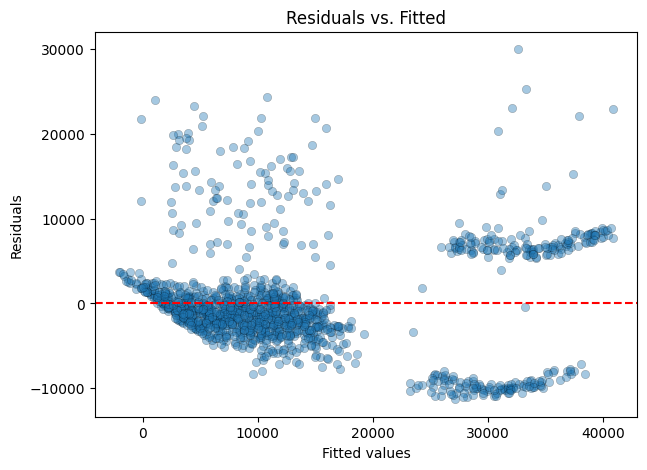

In [21]:
fitted = model.fittedvalues
resid = model.resid

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fitted, resid, alpha=0.4, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs. Fitted")
plt.show()

There's a visible fan/funnel shape and two diagonal "bands" of points (an artifact of the smoker/non-smoker split, since smoking status shifts charges by a near-constant large amount). This is a sign of **heteroscedasticity** — variance of residuals is not constant across fitted values. In a written report, this is worth flagging as a limitation (a log-transform of `charges` is a common fix, since insurance-cost data is right-skewed and multiplicative in nature).

Normality of Residuals — Q-Q Plot + Jarque-Bera/Omnibus:** A Q-Q plot compares residual quantiles to a theoretical normal distribution — points hugging the diagonal line indicate normality.

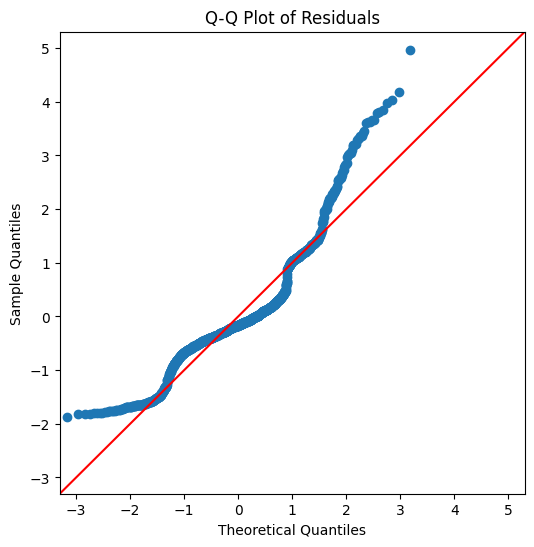

Omnibus:                      299.816   Durbin-Watson:                   2.089
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              716.552
Skew:                           1.211   Prob(JB):                    2.53e-156
Kurtosis:                       5.646   Cond. No.                         311.


In [22]:
fig = sm.qqplot(resid, line='45', fit=True)
fig.set_size_inches(6, 6)
plt.title("Q-Q Plot of Residuals")
plt.show()

print(model.summary().tables[2])

The Q-Q plot shows the right tail curving well above the 45° line — the residuals have a heavier right tail than a normal distribution, echoing the right-skew we saw in raw `charges`. The **Jarque-Bera** and **Omnibus** tests from the regression summary table both have p-values effectively 0.00, formally rejecting the null hypothesis of normally-distributed residuals. Combined with the funnel pattern above, this tells us OLS is a reasonable *first-pass* model but not the final word — a log-transformed target or a model that explicitly handles the smoker interaction (e.g. `bmi * smoker`) would likely fit better; still fine to present as the required baseline model for this assignment.

 Multicollinearity — Variance Inflation Factor (VIF):** VIF quantifies how much a predictor's variance is inflated due to correlation with other predictors. Rule of thumb: VIF > 5 (or 10) signals a multicollinearity problem. We check the continuous predictors.

In [23]:
X = sm.add_constant(df[['age', 'bmi', 'children']])
vif_df = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_df

,feature,VIF
0,const,1.000000
1,age,1.013754
2,bmi,1.012170
3,children,1.001797


All VIF values are ≈ 1.0–1.01 — essentially no multicollinearity among `age`, `bmi`, and `children`. This confirms what the correlation heatmap in Part 1 suggested, and means we can trust each coefficient's individual interpretation without worrying that shared variance among predictors is distorting the estimates.

## Summary

- Smoking status is overwhelmingly the strongest driver of insurance charges (both in the group-comparison test and the regression coefficient).
- Age and BMI have smaller but statistically robust positive effects; children has a modest positive effect.
- Sex has no significant effect; region has, at best, a weak and borderline effect — flagged as unreliable by the ANOVA/Kruskal-Wallis disagreement.
- The linear model explains ~75% of variance but shows heteroscedasticity and non-normal residuals, both traceable to the right-skewed nature of `charges` — worth naming explicitly as a limitation in the README write-up.

Part 3 (the interactive Streamlit dashboard covering these same analyses) is in `app.py`.